In [ ]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

In [2]:
color_list = {
    'naive': '#999999',
    'nf': '#31a354',
}

In [ ]:
global_type1 = {}
lengths = {}
avg_type1 = {}
for rho in [0.3, 0.6, 0.9]:
    global_type1[(rho, 'naive')], global_type1[(rho, 'nf')] = [], []
    avg_type1[(rho, 'naive')], avg_type1[(rho, 'nf')] = [], []
    lengths[(rho, 'naive')], lengths[(rho, 'nf')] = [], []

    savepath = f"experiments/results/pcr/pcr_rho_{rho}_train_2000_val_500"
    count = 0
    for seed in range(1000):
        filename = os.path.join(savepath, f"{seed}.pkl")
        try:
            with open(filename, 'rb') as f:
                res = pickle.load(f)
            count += 1
            for key in ['naive', 'nf']:
                global_type1[(rho, key)].append(res['global_pvalue'][key] < 0.05)
                lengths[(rho, key)].append(np.mean(res['intervals'][key][:, 1] - res['intervals'][key][:, 0]))
                avg_type1[(rho, key)].append(np.mean(res['pvalues'][key] < 0.05))
        except:
            for key in ['naive', 'nf']:
                global_type1[(rho, key)].append(np.nan)
                lengths[(rho, key)].append(np.nan)
                avg_type1[(rho, key)].append(np.nan)

    print(rho, "total:", count)

0.3 total: 422
0.6 total: 374
0.9 total: 294


In [4]:
print(pd.DataFrame(global_type1).mean())
print(pd.DataFrame(lengths).mean())
print(pd.DataFrame(avg_type1).mean())

0.3  naive    0.172986
     nf       0.035545
0.6  naive    0.213904
     nf       0.040107
0.9  naive    0.295918
     nf       0.027211
dtype: object
0.3  naive    0.468766
     nf       0.490102
0.6  naive    0.374082
     nf       0.385940
0.9  naive    0.231127
     nf       0.243778
dtype: float64
0.3  naive    0.122630
     nf       0.048578
0.6  naive    0.140820
     nf       0.048797
0.9  naive    0.230159
     nf       0.029478
dtype: float64


In [5]:
df_cover = pd.DataFrame(avg_type1).T.reset_index(names=['rho', 'method']).melt(id_vars=['rho', 'method'], value_name='type1').drop(columns=['variable'])
df_cover['coverage'] = 1 - df_cover['type1']

df_len = pd.DataFrame(lengths).T.reset_index(names=['rho', 'method']).melt(id_vars=['rho', 'method'], value_name='length').drop(columns=['variable'])

df_global_type1 = pd.DataFrame(global_type1).T.reset_index(names=['rho', 'method']).melt(id_vars=['rho', 'method'], value_name='type1').drop(columns=['variable'])

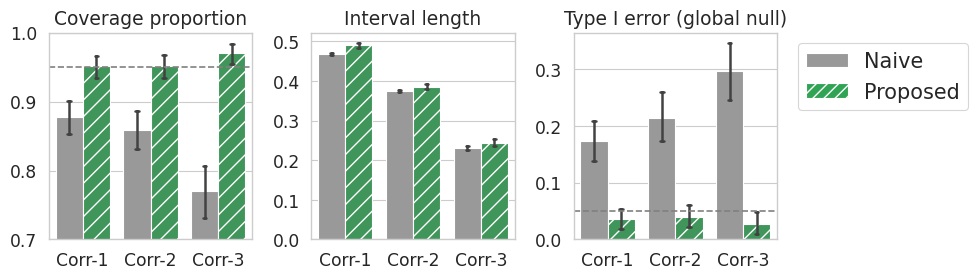

In [ ]:
sns.set_theme(context='paper', style='whitegrid', font_scale=1.4)
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
sns.barplot(ax=ax[0], data=df_cover, x='rho', y='coverage', capsize=.1, hue='method', palette=color_list)
ax[0].axhline(0.95, ls='--', color='grey')
ax[0].set_ylim(0.7, 1)
ax[0].set_title('Coverage proportion')
ax[0].set_ylabel('')
ax[0].set_xlabel(r'$\rho$')
ax[0].set_yticks([0.7, 0.8, 0.9, 1.0])
ax[0].legend().remove()
bars = ax[0].patches
bars[3].set_hatch('//')
bars[4].set_hatch('//')
bars[5].set_hatch('//')

sns.barplot(ax=ax[1], data=df_len, x='rho', y='length', capsize=.1, hue='method', palette=color_list)
ax[1].set_title(r'Interval length')
ax[1].set_ylabel('')
ax[1].set_xlabel(r'$\rho$')
ax[1].legend().remove()
bars = ax[1].patches
bars[3].set_hatch('//')
bars[4].set_hatch('//')
bars[5].set_hatch('//')

sns.barplot(ax=ax[2], data=df_global_type1, x='rho', y='type1', capsize=.1, hue='method', palette=color_list)
ax[2].axhline(.05, ls='--', color='grey')
ax[2].set_title('Type I error (global null)')
ax[2].set_ylabel('')
ax[2].set_xlabel(r'$\rho$')
ax[2].legend().remove()
bars = ax[2].patches
bars[3].set_hatch('//')
bars[4].set_hatch('//')
bars[5].set_hatch('//')

for j in range(3):
    ax[j].set_xticks([0, 1, 2], ['Corr-1', 'Corr-2', 'Corr-3'])
    ax[j].set_xlabel('')


labels = ['Naive', 'Proposed']
hatches = {'Naive': '', 'Proposed': '///'}
colors = {'Naive': '#999999', 'Proposed': '#31a354'}
handles = [
    Patch(facecolor=colors[m], hatch=hatches[m], edgecolor=None, label=m)
    for m in labels
]
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=15)

plt.tight_layout()
